# RAPID-MFA 17: Trouble shooting: negative inflows misspecified survival curves

# Descriptions

This variant of the stock-driven model shows the case of a declining stock over time (stock changes are negative), resulting in the right-hand side of the mass balance equation, $ stock\_changes = inflows - outflows $, being a negative value. However, if the survival of cohorts is assumed to be very long, the dynamic MFA model is incapable of generating sufficient outflows to at least match the negative stock changes, leaving no choice but to propagation of negative values to the inflows. This issue can be addressed by reducing the lifespan of the stocks, thereby maintaining positive inflows. 

### Exogenous variables
__Stock:__ Stock of concrete in buildings of Japan from _Tanikawa, H., Fishman, T., Okuoka, K., & Sugimoto, K. (2015). The weight of society over time and space: A comprehensive account of the construction material stock of Japan, 1945–2010. Journal of Industrial Ecology, 19(5), 778-791._

__Survival curve:__ mock values. We assume a survival curve following a normal distribution with a mean of 100 years and standard deviation of 50, befitting buildings.

__New survival curve:__ the 50 year lifetime used in the second MFA system comes from _Hashimoto, S., Tanikawa, H., & Moriguchi, Y. (2007). Where will large amounts of materials accumulated within the economy go?–A material flow analysis of construction minerals for Japan. Waste management, 27(12), 1725-1738._

### Notes
This example uses Normal distribution survival curves, but they can be replaced with any other curves.

### Relations with other RAPID-MFA codes
- `RAPID-MFA-2: The stock driven model`: The modelling steps are following those in this notebook.

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 

## 1. Load libraries

In [1]:
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt

## 2. Define example input data

In [2]:
# %% 2. Define example input data
input_data = pd.Series([0, 31486057.5, 65410878.57, 99107202.27, 132492117, 160901923.2, 185149478.3, 209922793.6, 234596408.8, 
                        257117352.3, 278288036.6, 305169804.9, 333999787.6, 362079720.7, 394283597.3, 436491733.7, 496818854.9,
                        557523678.3, 627640955.8, 717657119.6, 800886653.2, 889663754.1, 1004238157, 1142529301, 1302489463,
                        1487692220, 1665149918, 1895310208, 2166966624, 2322814545, 2470293459, 2635322311, 2809616095,
                        2998530046, 3220596794, 3408827301, 3579930000, 3750023483, 3915837361, 4090184054, 4231828356, 
                        4383518490, 4578553737, 4783994893, 4993880158, 5224416081, 5410345966, 5577072404, 5716021465, 
                        5866696773, 6000831861, 6161157555, 6291045843, 6376983735, 6453217604, 6526778793, 6575921584, 
                        6609032951, 6637217825, 6661744397, 6690061817, 6715424619, 6699369810, 6673910792, 6611510760, 
                        6550220899, 6489415242, 6429089964, 6369241269, 6309865392, 6250958598], 
                        name = 'stocks', 
                        index = [1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 
                                 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 
                                 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 
                                 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 
                                 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 
                                 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 
                                 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 
                                 2015]) 

# Parameters for the survival curve
ages = range(0, len(input_data)) 
mean = 100
std_dev = 50

# create the survival curve
survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev)

## 3. Run the stock-driven model

The steps from hereon are a repetition of notebook 2, but with different input data. If you want a more detailed account on how to do this, see notebook 2.

In [ ]:
# %% 3. Run the stock-driven model
units = {'time_interval':   'year', 
         'flows':           'tonnes/year', 
         'stocks':          'tonnes'}

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.
time_interval = 1
cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required
mfa_system = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])

mfa_system['stocks'] = input_data

# create survival curves matrix filled with zeros
survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]
   
# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system.loc[cohort, 'inflows'] = (
        mfa_system.loc[cohort, 'stocks'] - cohorts_survival_matrix.loc[cohort, : cohort - 1].sum()
    ) / survival_curves_matrix.loc[cohort, cohort]
    cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * mfa_system.loc[cohort, 'inflows']
    
mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

## 4. Identify the negative inflows issue

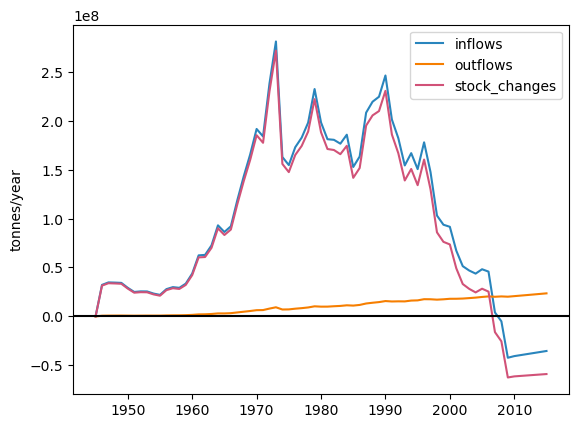

In [4]:
# Visualize the results of the MFA system
mfa_system[['inflows', 'outflows', 'stock_changes']].plot(ylabel=units["flows"],
                                                                color=["#2985BD", "#F67E00", "#D15278"])
plt.axhline(0, color='black') # add an exis line at y=0 to emphasize the negative inflows.

## 5. Solve the negative inflows issue with a new survival curve

In [ ]:
# Use the new survival curve parameters
mean = 50
std_dev = 16.66
survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev)

In [ ]:
# Recalculate the MFA model with the new survival curve
mfa_system = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])

mfa_system['stocks'] = input_data

# create survival curves matrix filled with zeros
survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]
   
# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system.loc[cohort, 'inflows'] = (
        mfa_system.loc[cohort, 'stocks'] - cohorts_survival_matrix.loc[cohort, : cohort - 1].sum()
    ) / survival_curves_matrix.loc[cohort, cohort]
    cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * mfa_system.loc[cohort, 'inflows']

mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

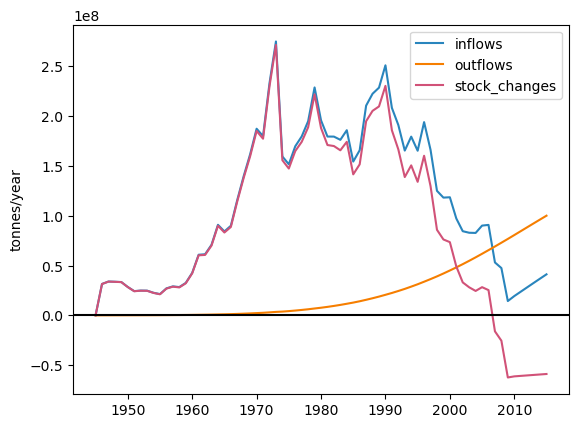

In [7]:
# Visualize the results of the new MFA system
mfa_system[['inflows', 'outflows', 'stock_changes']].plot(ylabel=units["flows"],
                                                                color=["#2985BD", "#F67E00", "#D15278"])
plt.axhline(0, color='black') # add an exis line at y=0 to emphasize the negative inflows.